In [237]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string
import csv
import requests

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import BernoulliNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.pipeline import Pipeline

import nltk

# nltk.download('punkt_tab')
# nltk.download('stopwords')

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from Sastrawi.StopWordRemover.StopWordRemover import StopWordRemover

from wordcloud import WordCloud

from io import StringIO

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Embedding, Bidirectional, LSTM, Dense, Dropout,
    Conv1D, GlobalMaxPooling1D, Input
)
from tensorflow.keras.preprocessing.text import Tokenizer as KerasTokenizer
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.utils.class_weight import compute_class_weight
from scipy.sparse import issparse

In [238]:
ankidroid_reviews_df = pd.read_csv('ankidroid_reviews.csv')

# Only drop rows missing 'content' — keeps 20K+ samples
ankidroid_reviews_clean_df = ankidroid_reviews_df.dropna(subset=['content'])

In [239]:
ankidroid_reviews_clean_df = ankidroid_reviews_clean_df.drop_duplicates()

reviews_count_after_delete_duplicate, column_count_after_delete_duplicate = ankidroid_reviews_clean_df.shape

In [240]:
ankidroid_reviews_clean_df.info()
ankidroid_reviews_clean_df

<class 'pandas.DataFrame'>
Index: 20251 entries, 0 to 20283
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   reviewId              20251 non-null  str  
 1   userName              20251 non-null  str  
 2   userImage             20251 non-null  str  
 3   content               20251 non-null  str  
 4   score                 20251 non-null  int64
 5   thumbsUpCount         20251 non-null  int64
 6   reviewCreatedVersion  17753 non-null  str  
 7   at                    20251 non-null  str  
 8   replyContent          4120 non-null   str  
 9   repliedAt             4120 non-null   str  
 10  appVersion            17753 non-null  str  
dtypes: int64(2), str(9)
memory usage: 1.9 MB


,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion
0,b97e4e05-e9a3-4142-9b03-5bafcec05d4d,MufinMcFlufin,https://play-lh.googleusercontent.com/a-/ALV-U...,I've used this app for a few years now and it'...,5,250,2.19.2,2024-11-24 06:14:09,NaN,NaN,2.19.2
1,097dc18a-4b89-46e3-9623-8813599248b5,m s,https://play-lh.googleusercontent.com/a-/ALV-U...,genuinely love anki 🫶🏾 makes my academic life ...,5,313,2.21.0,2025-07-19 01:51:18,NaN,NaN,2.21.0
2,655836d8-1504-4dab-ac6e-927e601cc01e,Andrew Bianchi,https://play-lh.googleusercontent.com/a-/ALV-U...,Anki Pro is a SCAM. It's not affiliated with t...,5,531,2.20.1,2025-01-24 23:54:10,"Hi, thanks for your encouraging words. Hope yo...",2025-03-26 15:55:18,2.20.1
3,004db3b7-4427-4d71-9fb7-53e487d65c4c,T Golden,https://play-lh.googleusercontent.com/a/ACg8oc...,"Excellent for spaced repetition! Also, use to ...",5,2,2.24.0,2026-05-12 23:41:27,NaN,NaN,2.24.0
4,8a7cd6c4-2541-4280-9f06-1f24f4a4cf3b,Kelsie Starcke,https://play-lh.googleusercontent.com/a-/ALV-U...,"why does the app need a ""high learning curve"" ...",1,0,2.24.0,2026-06-18 03:24:23,NaN,NaN,2.24.0
...,...,...,...,...,...,...,...,...,...,...,...
20279,2b4e2524-8709-4e74-866f-569dda2a21e5,Ger Ytu,https://play-lh.googleusercontent.com/a/ACg8oc...,😇😇😇,5,0,NaN,2025-11-07 20:00:27,NaN,NaN,NaN
20280,9774e6be-bbc0-48be-9a78-5ebfee275dfa,سنا فرهادیان,https://play-lh.googleusercontent.com/a/ACg8oc...,❤️,5,0,NaN,2025-12-15 01:29:44,NaN,NaN,NaN
20281,70ee743b-a7b8-4a0f-8d4e-bc50b76eba82,Shiquihno Josue Tovar Curto,https://play-lh.googleusercontent.com/a-/ALV-U...,❤️,5,0,NaN,2020-11-19 02:22:52,NaN,NaN,NaN
20282,25db027f-8d7e-4a86-978a-987c020eacf6,Hakam Lababneh,https://play-lh.googleusercontent.com/a/ACg8oc...,❤️❤️,5,0,NaN,2021-06-20 06:19:49,NaN,NaN,NaN


In [241]:
def cleaning_text(text):
    text = re.sub(r'@[A-Za-z0-9]+', '', text)   # Remove Metion
    text =  re.sub(r'#[A-Za-z]0-9+', '', text)  # Remove hashtag
    text = re.sub(r'RT[\s]', '', text)  # Remove RT (Retweet)
    text = re.sub(r'http\S+', '', text) # Remove Link
    text = re.sub(r'[0-9]+', '', text)  # Remove Number
    text = re.sub(r'[^\w\s]', '', text) # Remove Character Except Number and Alphabet

    text = text.replace('\n', ' ')
    text = text.translate(str.maketrans('', '', string.punctuation))

    return text

def casefolding_text(text):
    return text.lower()

def tokenizing_text(text):
    return word_tokenize(text)

def filtering_text(text):
    list_stopwords = set(stopwords.words('english'))

    negations_to_keep = {
        'not', 'no', 'nor', 'don', "don't", 'ain', 'aren', "aren't", 'couldn', "couldn't", 'didn', "didn't", 'doesn', "doesn't", 'hadn', "hadn't", 'hasn', "hasn't", 'haven', "haven't", 'isn', "isn't", 'mightn', "mightn't", 'mustn', "mustn'n", 'needn', "needn't", 'shan', "shan't", 'shouldn', "shouldn't", 'weren', "weren't", 'won', "won't", 'wouldn', "wouldn't"
    }
    list_stopwords = list_stopwords - negations_to_keep

    custom_stopwords = [
        # General
        'app', 'anki', 'ankidroid', 'would', 'also', 'really', 'much', 'ive', 'im', 'get', 'use', 'one', 'even', 'well', 'thats', 'time', 'make', 'way', 'thing', 'things'

        # Flashcard specific
        'card', 'cards', 'deck', 'decks', 'flashcard', 'flashcards', 'study', 'studying', 'studies', 'review', 'reviews',

        # Device Specific
        'phone', 'computer', 'tab', 'tablet', 'ipad', 'android', 'ios', 'version', 'screen',
    ]

    list_stopwords.update(custom_stopwords)

    filtered = []

    for txt in text:
        if txt not in list_stopwords:
            filtered.append(txt)

    return filtered

def stemming_text(text):
    stemmer = PorterStemmer()

    return [stemmer.stem(word) for word in text]

def to_sentence(list_words):
    return ' '.join(word for word in list_words)

In [242]:
# Cleaning
ankidroid_reviews_clean_df['text_clean'] = ankidroid_reviews_clean_df['content'].apply(cleaning_text)

# Case Folding
ankidroid_reviews_clean_df['text_casefolding'] = ankidroid_reviews_clean_df['text_clean'].apply(casefolding_text)

# Tokenizing
ankidroid_reviews_clean_df['text_tokenized'] = ankidroid_reviews_clean_df['text_casefolding'].apply(tokenizing_text)

# Filtering
ankidroid_reviews_clean_df['text_filtered'] = ankidroid_reviews_clean_df['text_tokenized'].apply(filtering_text)

# Stemming
ankidroid_reviews_clean_df['text_stemmed'] = ankidroid_reviews_clean_df['text_filtered'].apply(stemming_text)

# Join back to sentence
ankidroid_reviews_clean_df['text_final'] = ankidroid_reviews_clean_df['text_stemmed'].apply(to_sentence)

In [243]:
ankidroid_reviews_clean_df[
    [
        'content', 'text_clean', 'text_casefolding', 'text_tokenized', 'text_filtered', 'text_stemmed', 'text_final'
    ]
].head()

,content,text_clean,text_casefolding,text_tokenized,text_filtered,text_stemmed,text_final
0,I've used this app for a few years now and it'...,Ive used this app for a few years now and its ...,ive used this app for a few years now and its ...,"[ive, used, this, app, for, a, few, years, now...","[used, years, immensely, helpful, memorizing, ...","[use, year, immens, help, memor, whatev, digit...",use year immens help memor whatev digit write ...
1,genuinely love anki 🫶🏾 makes my academic life ...,genuinely love anki makes my academic life so...,genuinely love anki makes my academic life so...,"[genuinely, love, anki, makes, my, academic, l...","[genuinely, love, makes, academic, life, easie...","[genuin, love, make, academ, life, easier, lea...",genuin love make academ life easier learn almo...
2,Anki Pro is a SCAM. It's not affiliated with t...,Anki Pro is a SCAM Its not affiliated with the...,anki pro is a scam its not affiliated with the...,"[anki, pro, is, a, scam, its, not, affiliated,...","[pro, scam, not, affiliated, team, closed, sou...","[pro, scam, not, affili, team, close, sourc, e...",pro scam not affili team close sourc expens ri...
3,"Excellent for spaced repetition! Also, use to ...",Excellent for spaced repetition Also use to re...,excellent for spaced repetition also use to re...,"[excellent, for, spaced, repetition, also, use...","[excellent, spaced, repetition, remind, practi...","[excel, space, repetit, remind, practic, probl...",excel space repetit remind practic problem spe...
4,"why does the app need a ""high learning curve"" ...",why does the app need a high learning curve to...,why does the app need a high learning curve to...,"[why, does, the, app, need, a, high, learning,...","[need, high, learning, curve, theyre, flash, a...","[need, high, learn, curv, theyr, flash, aw, un...",need high learn curv theyr flash aw unfriendli...


In [244]:
def score_to_sentiment(score):
    if score >= 4:
        return 'positive'
    elif score <= 2:
        return 'negative'
    else:
        return 'neutral'

In [245]:
ankidroid_reviews_clean_df['polarity'] = ankidroid_reviews_clean_df['score'].apply(score_to_sentiment)
print(ankidroid_reviews_clean_df['polarity'].value_counts())
print(f'\nTotal samples: {len(ankidroid_reviews_clean_df)}')

polarity
positive    17917
negative     1564
neutral       770
Name: count, dtype: int64

Total samples: 20251


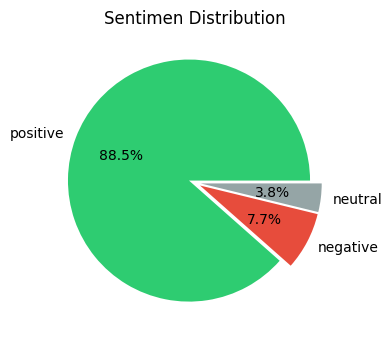

In [246]:
polarity_counts = ankidroid_reviews_clean_df['polarity'].value_counts()

color_map = {'positive': '#2ecc71', 'negative': '#e74c3c', 'neutral': '#95a5a6'}
colors = [color_map.get(p, '#34495e') for p in polarity_counts.index.to_list()]
explode = tuple([0.05] * len(polarity_counts))

plt.figure(figsize=(4, 4))
plt.pie(
    polarity_counts,
    labels=polarity_counts.index.to_list(),
    autopct='%1.1f%%',
    colors=colors,
    explode=explode,
    textprops={
        'fontsize' : 10
    }
)

plt.title('Sentimen Distribution', fontsize=12)
plt.tight_layout()
plt.show()

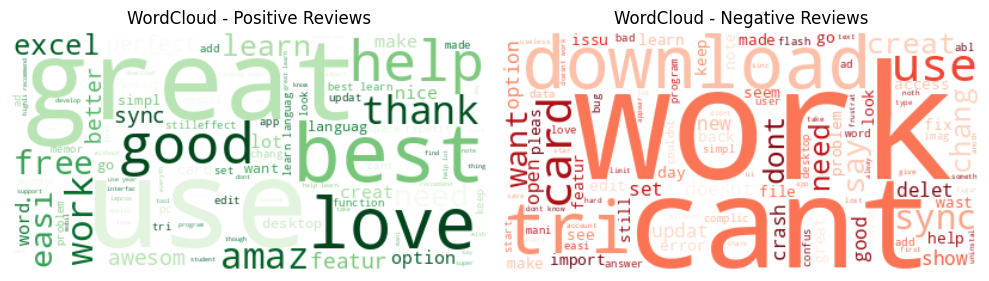

In [247]:
text_positive = ' '.join(ankidroid_reviews_clean_df[ankidroid_reviews_clean_df['polarity'] == 'positive']['text_final'].astype(str))
text_negative = ' '.join(ankidroid_reviews_clean_df[ankidroid_reviews_clean_df['polarity'] == 'negative']['text_final'].astype(str))

# Generate WordClouds
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

wc_pos = WordCloud(width=400, height=200, background_color='white', colormap='Greens', max_words=100).generate(text_positive)
axes[0].imshow(wc_pos, interpolation='bilinear')
axes[0].set_title('WordCloud - Positive Reviews', fontsize=12)
axes[0].axis('off')

wc_neg = WordCloud(width=400, height=200, background_color='white', colormap='Reds', max_words=100).generate(text_negative)
axes[1].imshow(wc_neg, interpolation='bilinear')
axes[1].set_title('WordCloud - Negative Reviews', fontsize=12)
axes[1].axis('off')

plt.tight_layout()
plt.show()

In [248]:
label_map = {'negative': 0, 'neutral': 1, 'positive': 2}
ankidroid_reviews_clean_df['label'] = ankidroid_reviews_clean_df['polarity'].map(label_map)

X_text = ankidroid_reviews_clean_df['text_casefolding'].values
y_labels = ankidroid_reviews_clean_df['label'].values

X_train_text, X_test_text, y_train_12, y_test_12 = train_test_split(
    X_text, y_labels, test_size=0.2, random_state=42, stratify=y_labels.tolist() # type: ignore
)

VOCAB_SIZE = 10000
MAX_LEN = 150

tokenizer_keras = KerasTokenizer(num_words=VOCAB_SIZE, oov_token='<OOV>')
tokenizer_keras.fit_on_texts(X_train_text)
# X_sequences = tokenizer_keras.texts_to_sequences(X_text)

# from tensorflow.keras.preprocessing.sequence import pad_sequences
# X_padded = pad_sequences(X_sequences, maxlen=MAX_LEN, padding='post', truncating='post')

# X_train_seq, X_test_seq, y_train_12, y_test_12 = train_test_split(
#     X_padded, y_labels, test_size=0.2, random_state=42, stratify=y_labels.tolist() # type: ignore
# )

y_train_12_cat = to_categorical(y_train_12, num_classes=3)
y_test_12_cat = to_categorical(y_test_12, num_classes=3)

class_weights_arr = compute_class_weight('balanced', classes=np.unique(y_train_12), y=y_train_12)
class_weight_dict = dict(enumerate(class_weights_arr))

X_train_sequences = tokenizer_keras.texts_to_sequences(X_train_text)
X_test_sequences = tokenizer_keras.texts_to_sequences(X_test_text)

from tensorflow.keras.preprocessing.sequence import pad_sequences
X_train_seq = pad_sequences(X_train_sequences, maxlen=MAX_LEN, padding='post', truncating='post')
X_test_seq = pad_sequences(X_test_sequences, maxlen=MAX_LEN, padding='post', truncating='post')

print(f'Training samples: {len(X_train_seq)}')
print(f'Test samples: {len(X_test_seq)}')
print(f'Vocabulary size: {VOCAB_SIZE}')
print(f'Max sequence length: {MAX_LEN}')
print(f'Class weights: {class_weight_dict}')

Training samples: 16200
Test samples: 4051
Vocabulary size: 10000
Max sequence length: 150
Class weights: {0: np.float64(4.316546762589928), 1: np.float64(8.766233766233766), 2: np.float64(0.37675294774297075)}


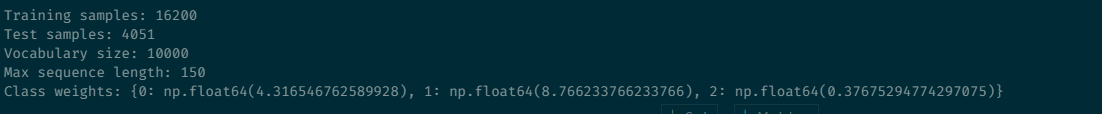

In [249]:
model_lstm = Sequential([
    Embedding(VOCAB_SIZE, 64, input_length=MAX_LEN),
    Bidirectional(LSTM(32)),
    Dropout(0.4),
    Dense(32, activation='relu'),
    Dropout(0.3),
    Dense(3, activation='softmax')
])

model_lstm.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model_lstm.summary()

early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

history_lstm = model_lstm.fit(
    X_train_seq, y_train_12_cat,
    epochs=15,
    batch_size=64,
    validation_split=0.1,
    class_weight=class_weight_dict,
    callbacks=[early_stop],
    verbose=1
)

# Evaluate
y_pred_train_lstm = np.argmax(model_lstm.predict(X_train_seq), axis=1)
y_pred_test_lstm = np.argmax(model_lstm.predict(X_test_seq), axis=1)

accuracy_train_lstm = accuracy_score(y_train_12, y_pred_train_lstm)
accuracy_test_lstm = accuracy_score(y_test_12, y_pred_test_lstm)

print(f'\n=== Scheme 1: Bi-LSTM + Embedding + 80/20 ===')
print(f'Accuracy_Train: {accuracy_train_lstm}')
print(f'Accuracy_Test: {accuracy_test_lstm}')

print(f'\nClassification Report (Train):')
print(classification_report(y_train_12, y_pred_train_lstm))
print(f'Classification Report (Test):')
print(classification_report(y_test_12, y_pred_test_lstm))


/home/kuro/miniconda3/envs/dicoding-submission/lib/python3.13/site-packages/keras/src/layers/core/embedding.py:123: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_17"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_10 (Embedding)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_6 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_34 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_41 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_35 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_42 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15


228/228 ━━━━━━━━━━━━━━━━━━━━ 18s 61ms/step - accuracy: 0.6600 - loss: 0.9594 - val_accuracy: 0.7957 - val_loss: 0.5229
Epoch 2/15
228/228 ━━━━━━━━━━━━━━━━━━━━ 12s 54ms/step - accuracy: 0.8012 - loss: 0.7307 - val_accuracy: 0.8179 - val_loss: 0.4727
Epoch 3/15
228/228 ━━━━━━━━━━━━━━━━━━━━ 13s 55ms/step - accuracy: 0.8573 - loss: 0.5997 - val_accuracy: 0.8395 - val_loss: 0.5026
Epoch 4/15
228/228 ━━━━━━━━━━━━━━━━━━━━ 13s 55ms/step - accuracy: 0.8859 - loss: 0.4563 - val_accuracy: 0.8080 - val_loss: 0.5451
Epoch 5/15
228/228 ━━━━━━━━━━━━━━━━━━━━ 12s 54ms/step - accuracy: 0.9046 - loss: 0.3701 - val_accuracy: 0.8290 - val_loss: 0.4552
Epoch 6/15
228/228 ━━━━━━━━━━━━━━━━━━━━ 13s 55ms/step - accuracy: 0.8883 - loss: 0.3323 - val_accuracy: 0.8728 - val_loss: 0.4200
Epoch 7/15
228/228 ━━━━━━━━━━━━━━━━━━━━ 13s 55ms/step - accuracy: 0.9180 - loss: 0.2545 - val_accuracy: 0.8722 - val_loss: 0.4665
Epoch 8/15
228/228 ━━━━━━━━━━━━━━━━━━━━ 13s 57ms/step - accuracy: 0.9131 - loss: 0.2274 - val_accurac

=== Classification Report: Bi-LSTM (Test) ===
              precision    recall  f1-score   support

    negative       0.56      0.56      0.56       313
     neutral       0.16      0.38      0.23       154
    positive       0.96      0.91      0.93      3584

    accuracy                           0.86      4051
   macro avg       0.56      0.62      0.57      4051
weighted avg       0.90      0.86      0.88      4051



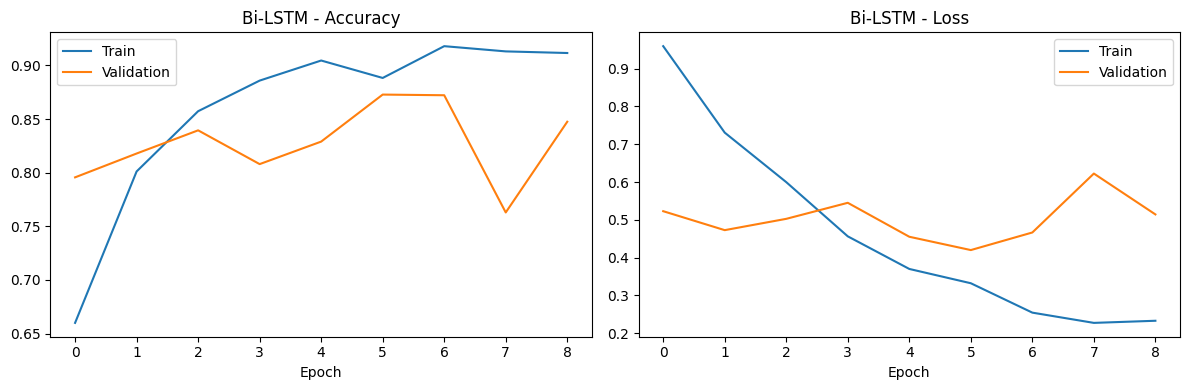

In [250]:
print('=== Classification Report: Bi-LSTM (Test) ===')
print(classification_report(y_test_12, y_pred_test_lstm, target_names=['negative', 'neutral', 'positive']))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history_lstm.history['accuracy'], label='Train')
axes[0].plot(history_lstm.history['val_accuracy'], label='Validation')
axes[0].set_title('Bi-LSTM - Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(history_lstm.history['loss'], label='Train')
axes[1].plot(history_lstm.history['val_loss'], label='Validation')
axes[1].set_title('Bi-LSTM - Loss')
axes[1].set_xlabel('Epoch')
axes[1].legend()

plt.tight_layout()
plt.show()

In [251]:
model_cnn = Sequential([
    Embedding(VOCAB_SIZE, 64, input_length=MAX_LEN),
    Conv1D(64, 5, activation='relu'),
    GlobalMaxPooling1D(),
    Dropout(0.4),
    Dense(32, activation='relu'),
    Dropout(0.3),
    Dense(3, activation='softmax')
])

model_cnn.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model_cnn.summary()

early_stop_cnn = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

history_cnn = model_cnn.fit(
    X_train_seq, y_train_12_cat,
    epochs=15,
    batch_size=64,
    validation_split=0.1,
    class_weight=class_weight_dict,
    callbacks=[early_stop_cnn],
    verbose=1
)

y_pred_train_cnn = np.argmax(model_cnn.predict(X_train_seq), axis=1)
y_pred_test_cnn = np.argmax(model_cnn.predict(X_test_seq), axis=1)

accuracy_train_cnn = accuracy_score(y_train_12, y_pred_train_cnn)
accuracy_test_cnn = accuracy_score(y_test_12, y_pred_test_cnn)

print(f'\n=== Scheme 2: 1D CNN + Embedding + 80/20 ===')
print(f'Accuracy_Train: {accuracy_train_cnn}')
print(f'Accuracy_Test: {accuracy_test_cnn}')

print(f'\nClassification Report (Train):')
print(classification_report(y_train_12, y_pred_train_cnn))
print(f'Classification Report (Test):')
print(classification_report(y_test_12, y_pred_test_cnn))


/home/kuro/miniconda3/envs/dicoding-submission/lib/python3.13/site-packages/keras/src/layers/core/embedding.py:123: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_18"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_11 (Embedding)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_4 (Conv1D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d_4          │ ?                      │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_36 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_43 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_37 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_44 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
228/228 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.6059 - loss: 0.9973 - val_accuracy: 0.7728 - val_loss: 0.5812
Epoch 2/15
228/228 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.8143 - loss: 0.7769 - val_accuracy: 0.8259 - val_loss: 0.4671
Epoch 3/15
228/228 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.8622 - loss: 0.6469 - val_accuracy: 0.8315 - val_loss: 0.4465
Epoch 4/15
228/228 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.8870 - loss: 0.5293 - val_accuracy: 0.8531 - val_loss: 0.4168
Epoch 5/15
228/228 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.9160 - loss: 0.3894 - val_accuracy: 0.8784 - val_loss: 0.3578
Epoch 6/15
228/228 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.9340 - loss: 0.2861 - val_accuracy: 0.8728 - val_loss: 0.4265
Epoch 7/15
228/228 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.9414 - loss: 0.2162 - val_accuracy: 0.8722 - val_loss: 0.4225
Epoch 8/15
228/228 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.9529 - loss: 0.1895 - val_accu

=== Classification Report: 1D CNN (Test) ===
              precision    recall  f1-score   support

    negative       0.50      0.64      0.56       313
     neutral       0.18      0.31      0.23       154
    positive       0.97      0.91      0.94      3584

    accuracy                           0.87      4051
   macro avg       0.55      0.62      0.58      4051
weighted avg       0.90      0.87      0.88      4051



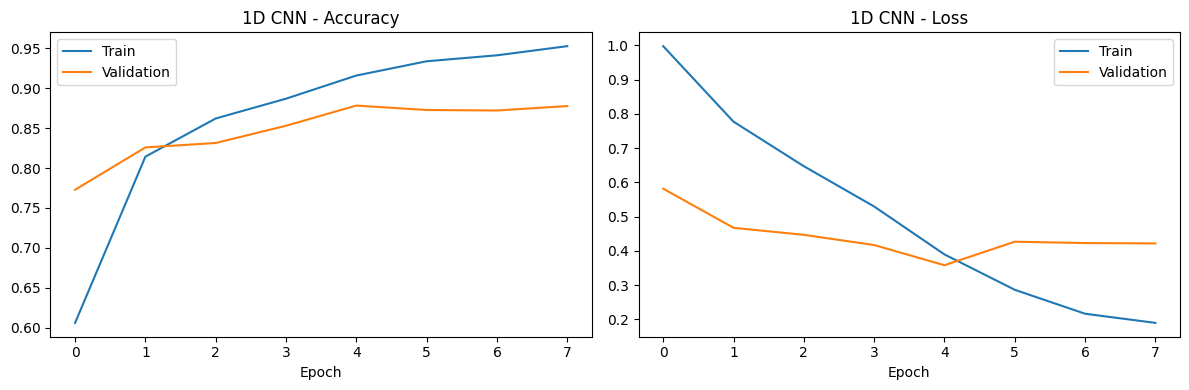

In [252]:
print('=== Classification Report: 1D CNN (Test) ===')
print(classification_report(y_test_12, y_pred_test_cnn, target_names=['negative', 'neutral', 'positive']))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history_cnn.history['accuracy'], label='Train')
axes[0].plot(history_cnn.history['val_accuracy'], label='Validation')
axes[0].set_title('1D CNN - Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(history_cnn.history['loss'], label='Train')
axes[1].plot(history_cnn.history['val_loss'], label='Validation')
axes[1].set_title('1D CNN - Loss')
axes[1].set_xlabel('Epoch')
axes[1].legend()

plt.tight_layout()
plt.show()

In [253]:
tfidf = TfidfVectorizer(max_features=10000, min_df=2, max_df=0.95, ngram_range=(1, 2), sublinear_tf=True)
X_text_all = ankidroid_reviews_clean_df['text_casefolding']
y_labels_all = ankidroid_reviews_clean_df['label'].values

X_train_text, X_test_text, y_train_3, y_test_3 = train_test_split(
    X_text_all, y_labels_all, test_size=0.3, random_state=42, stratify=y_labels_all.tolist() # type: ignore
)

X_train_tfidf = tfidf.fit_transform(X_train_text)

X_test_tfidf = tfidf.transform(X_test_text)

X_train_dense = X_train_tfidf.toarray()
X_test_dense = X_test_tfidf.toarray()

y_train_3_cat = to_categorical(y_train_3, num_classes=3)
y_test_3_cat = to_categorical(y_test_3, num_classes=3)

class_weights_3 = compute_class_weight('balanced', classes=np.unique(y_train_3), y=y_train_3)
class_weight_dict_3 = dict(enumerate(class_weights_3))

model_dense = Sequential([
    Input(shape=(X_train_dense.shape[1],)),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(3, activation='softmax')
])

model_dense.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model_dense.summary()

early_stop_dense = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

history_dense = model_dense.fit(
    X_train_dense, y_train_3_cat,
    epochs=20,
    batch_size=128,
    validation_split=0.1,
    class_weight=class_weight_dict_3,
    callbacks=[early_stop_dense],
    verbose=1
)

# Evaluate
y_pred_train_dense = np.argmax(model_dense.predict(X_train_dense), axis=1)
y_pred_test_dense = np.argmax(model_dense.predict(X_test_dense), axis=1)

accuracy_train_dense = accuracy_score(y_train_3, y_pred_train_dense)
accuracy_test_dense = accuracy_score(y_test_3, y_pred_test_dense)

print(f'\n=== Scheme 3: Dense NN + TF-IDF + 70/30 ===')
print(f'Accuracy_Train: {accuracy_train_dense}')
print(f'Accuracy_Test: {accuracy_test_dense}')

print(f'\nClassification Report (Train):')
print(classification_report(y_train_3, y_pred_train_dense))
print(f'Classification Report (Test):')
print(classification_report(y_test_3, y_pred_test_dense))


Model: "sequential_19"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_45 (Dense)                │ (None, 256)            │     2,560,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_38 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_46 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_39 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_47 (Dense)                │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,593,539 (9.89 MB)

 Trainable params: 2,593,539 (9.89 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - accuracy: 0.7136 - loss: 0.9326 - val_accuracy: 0.7913 - val_loss: 0.5724
Epoch 2/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.8511 - loss: 0.5999 - val_accuracy: 0.7821 - val_loss: 0.5632
Epoch 3/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.8929 - loss: 0.3422 - val_accuracy: 0.8293 - val_loss: 0.4386
Epoch 4/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.9357 - loss: 0.1868 - val_accuracy: 0.8780 - val_loss: 0.4211
Epoch 5/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.9580 - loss: 0.1227 - val_accuracy: 0.8879 - val_loss: 0.4198
Epoch 6/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.9701 - loss: 0.0912 - val_accuracy: 0.8724 - val_loss: 0.4332
Epoch 7/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.9708 - loss: 0.0757 - val_accuracy: 0.8935 - val_loss: 0.4613
Epoch 8/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.9741 - loss: 0.0666 - val_accu

=== Classification Report: Dense NN + TF-IDF (Test) ===
              precision    recall  f1-score   support

    negative       0.58      0.60      0.59       469
     neutral       0.15      0.19      0.17       231
    positive       0.96      0.94      0.95      5376

    accuracy                           0.88      6076
   macro avg       0.56      0.58      0.57      6076
weighted avg       0.90      0.88      0.89      6076



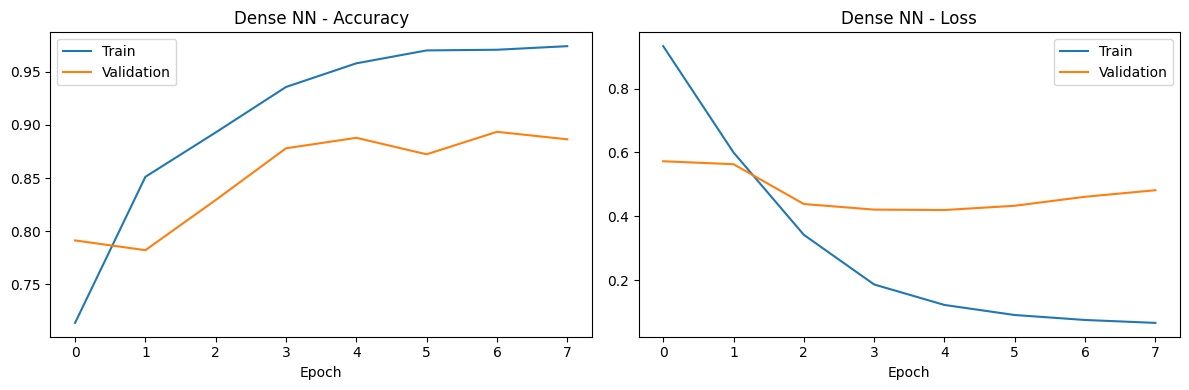

In [254]:
print('=== Classification Report: Dense NN + TF-IDF (Test) ===')
print(classification_report(y_test_3, y_pred_test_dense, target_names=['negative', 'neutral', 'positive']))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history_dense.history['accuracy'], label='Train')
axes[0].plot(history_dense.history['val_accuracy'], label='Validation')
axes[0].set_title('Dense NN - Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(history_dense.history['loss'], label='Train')
axes[1].plot(history_dense.history['val_loss'], label='Validation')
axes[1].set_title('Dense NN - Loss')
axes[1].set_xlabel('Epoch')
axes[1].legend()

plt.tight_layout()
plt.show()

In [255]:
tfidf = TfidfVectorizer(max_features=10000, min_df=2, max_df=0.95, ngram_range=(1, 2), sublinear_tf=True)
X_text_all = ankidroid_reviews_clean_df['text_casefolding']
y_labels_all = ankidroid_reviews_clean_df['label'].values

X_train_text, X_test_text, y_train_3, y_test_3 = train_test_split(
    X_text_all, y_labels_all, test_size=0.3, random_state=42, stratify=y_labels_all.tolist() # type: ignore
)

X_train_tfidf = tfidf.fit_transform(X_train_text)

X_test_tfidf = tfidf.transform(X_test_text)

X_train_dense = X_train_tfidf.toarray()
X_test_dense = X_test_tfidf.toarray()

y_train_3_cat = to_categorical(y_train_3, num_classes=3)
y_test_3_cat = to_categorical(y_test_3, num_classes=3)

class_weights_3 = compute_class_weight('balanced', classes=np.unique(y_train_3), y=y_train_3)
class_weight_dict_3 = dict(enumerate(class_weights_3))

model_dense = Sequential([
    Input(shape=(X_train_dense.shape[1],)),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(3, activation='softmax')
])

model_dense.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model_dense.summary()

early_stop_dense = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

history_dense = model_dense.fit(
    X_train_dense, y_train_3_cat,
    epochs=20,
    batch_size=128,
    validation_split=0.1,
    class_weight=class_weight_dict_3,
    callbacks=[early_stop_dense],
    verbose=1
)

y_pred_train_dense = np.argmax(model_dense.predict(X_train_dense), axis=1)
y_pred_test_dense = np.argmax(model_dense.predict(X_test_dense), axis=1)

accuracy_train_dense = accuracy_score(y_train_3, y_pred_train_dense)
accuracy_test_dense = accuracy_score(y_test_3, y_pred_test_dense)

print(f'\n=== Scheme 3: Dense NN + TF-IDF + 70/30 ===')
print(f'Accuracy_Train: {accuracy_train_dense}')
print(f'Accuracy_Test: {accuracy_test_dense}')

print(f'\nClassification Report (Train):')
print(classification_report(y_train_3, y_pred_train_dense))
print(f'Classification Report (Test):')
print(classification_report(y_test_3, y_pred_test_dense))


Model: "sequential_20"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_48 (Dense)                │ (None, 256)            │     2,560,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_40 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_49 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_41 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_50 (Dense)                │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,593,539 (9.89 MB)

 Trainable params: 2,593,539 (9.89 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - accuracy: 0.7919 - loss: 0.9289 - val_accuracy: 0.7489 - val_loss: 0.6212
Epoch 2/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.8404 - loss: 0.6049 - val_accuracy: 0.8159 - val_loss: 0.4658
Epoch 3/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.8961 - loss: 0.3444 - val_accuracy: 0.8152 - val_loss: 0.4795
Epoch 4/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.9333 - loss: 0.1799 - val_accuracy: 0.8554 - val_loss: 0.4528
Epoch 5/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.9580 - loss: 0.1142 - val_accuracy: 0.8843 - val_loss: 0.4306
Epoch 6/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.9697 - loss: 0.0861 - val_accuracy: 0.8632 - val_loss: 0.4647
Epoch 7/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.9711 - loss: 0.0807 - val_accuracy: 0.8568 - val_loss: 0.5069
Epoch 8/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.9744 - loss: 0.0696 - val_accu

=== Classification Report: Dense NN + TF-IDF (Test) ===
              precision    recall  f1-score   support

    negative       0.56      0.58      0.57       469
     neutral       0.14      0.19      0.16       231
    positive       0.95      0.93      0.94      5376

    accuracy                           0.88      6076
   macro avg       0.55      0.57      0.56      6076
weighted avg       0.89      0.88      0.88      6076



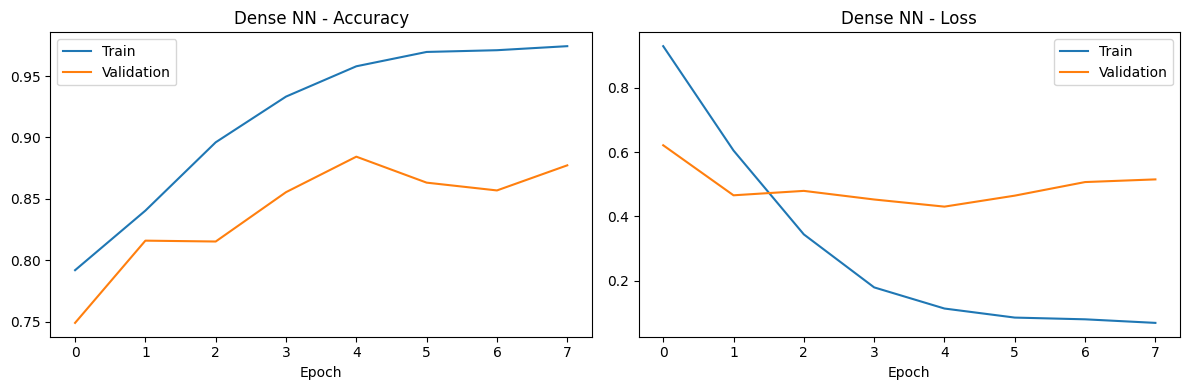

In [256]:
print('=== Classification Report: Dense NN + TF-IDF (Test) ===')
print(classification_report(y_test_3, y_pred_test_dense, target_names=['negative', 'neutral', 'positive']))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history_dense.history['accuracy'], label='Train')
axes[0].plot(history_dense.history['val_accuracy'], label='Validation')
axes[0].set_title('Dense NN - Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(history_dense.history['loss'], label='Train')
axes[1].plot(history_dense.history['val_loss'], label='Validation')
axes[1].set_title('Dense NN - Loss')
axes[1].set_xlabel('Epoch')
axes[1].legend()

plt.tight_layout()
plt.show()

In [257]:
print("--- Training Traditional ML Models ---\n")

rf_model = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=10000, min_df=2, max_df=0.95, ngram_range=(1, 2), sublinear_tf=True)),
    ('classifier', RandomForestClassifier(n_estimators=100, random_state=42, class_weight="balanced"))
])
rf_model.fit(X_train_text, y_train_3)

y_pred_train_rf = rf_model.predict(X_train_text)
y_pred_test_rf = rf_model.predict(X_test_text)

accuracy_train_rf = accuracy_score(y_train_3, y_pred_train_rf)
accuracy_test_rf = accuracy_score(y_test_3, y_pred_test_rf)

print("Random Forest Accuracy_Train:", accuracy_train_rf)
print("Random Forest Accuracy_Test:", accuracy_test_rf)
print("Random Forest Classification Report:")
print(classification_report(y_test_3, y_pred_test_rf))
print("="*50 + "\n")


--- Training Traditional ML Models ---

Random Forest Accuracy_Train: 0.9949206349206349
Random Forest Accuracy_Test: 0.8905529953917051
Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.76      0.13      0.23       469
           1       0.00      0.00      0.00       231
           2       0.89      0.99      0.94      5376

    accuracy                           0.89      6076
   macro avg       0.55      0.38      0.39      6076
weighted avg       0.85      0.89      0.85      6076




In [258]:
# 2. Logistic Regression 

lr_model = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=10000, min_df=2, max_df=0.95, ngram_range=(1, 2), sublinear_tf=True)),
    ('classifier', LogisticRegression(max_iter=1000, random_state=42, class_weight="balanced"))
])
lr_model.fit(X_train_text, y_train_3)

y_pred_train_lr = lr_model.predict(X_train_text)
y_pred_test_lr = lr_model.predict(X_test_text)

accuracy_train_lr = accuracy_score(y_train_3, y_pred_train_lr)
accuracy_test_lr = accuracy_score(y_test_3, y_pred_test_lr)

print("Logistic Regression Accuracy_Train:", accuracy_train_lr)
print("Logistic Regression Accuracy_Test:", accuracy_test_lr)
print("Logistic Regression Classification Report:")
print(classification_report(y_test_3, y_pred_test_lr))
print("="*50 + "\n")


Logistic Regression Accuracy_Train: 0.9238800705467373
Logistic Regression Accuracy_Test: 0.8660302830809743
Logistic Regression Classification Report:
              precision    recall  f1-score   support

           0       0.50      0.70      0.58       469
           1       0.20      0.39      0.27       231
           2       0.98      0.90      0.94      5376

    accuracy                           0.87      6076
   macro avg       0.56      0.67      0.59      6076
weighted avg       0.91      0.87      0.88      6076




In [259]:
# 3. Naive Bayes Classifier
nb_model = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=10000, min_df=2, max_df=0.95, ngram_range=(1, 2), sublinear_tf=True)),
    ('classifier', BernoulliNB())
])
nb_model.fit(X_train_text, y_train_3)

y_pred_train_nb = nb_model.predict(X_train_text)
y_pred_test_nb = nb_model.predict(X_test_text)

accuracy_train_nb = accuracy_score(y_train_3, y_pred_train_nb)
accuracy_test_nb = accuracy_score(y_test_3, y_pred_test_nb)

print("Naive Bayes Accuracy_Train:", accuracy_train_nb)
print("Naive Bayes Accuracy_Test:", accuracy_test_nb)
print("Naive Bayes Classification Report:")
print(classification_report(y_test_3, y_pred_test_nb))


Naive Bayes Accuracy_Train: 0.844373897707231
Naive Bayes Accuracy_Test: 0.8266951942067149
Naive Bayes Classification Report:
              precision    recall  f1-score   support

           0       0.43      0.41      0.42       469
           1       0.11      0.26      0.16       231
           2       0.94      0.89      0.91      5376

    accuracy                           0.83      6076
   macro avg       0.49      0.52      0.50      6076
weighted avg       0.87      0.83      0.84      6076



In [260]:
# === SCHEME 5: INFERENCE / TESTING ===
def predict_sentiment(text, model):
    cleaned = cleaning_text(text)
    casefolded = casefolding_text(cleaned)
    tokenized = tokenizing_text(casefolded)
    filtered = filtering_text(tokenized)
    stemmed = stemming_text(filtered)
    final_text = to_sentence(stemmed)
    
    # vectorized_text = vectorizer.transform([final_text])
    
    pred = model.predict([final_text])[0]
    
    sentiment_map = {0: "negatif", 1: "netral", 2: "positif"}
    return sentiment_map[pred]

test_sentences = [
    "Aplikasi ini sangat bagus dan sangat membantu saya belajar untuk ujian!",
    "Banyak bug, aplikasinya sering crash saat saya membuka deck kartu.",
    "Aplikasi ini lumayan, tapi butuh banyak perbaikan dari sisi UI."
]

print("--- Hasil Inferensi Menggunakan Random Forest ---")
for sentence in test_sentences:
    print(f"Teks: {sentence}")
    print(f"Prediksi: {predict_sentiment(sentence, rf_model)}\n")

print("--- Hasil Inferensi Menggunakan Logistic Regression ---")
for sentence in test_sentences:
    print(f"Teks: {sentence}")
    print(f"Prediksi: {predict_sentiment(sentence, lr_model)}\n")

print("--- Hasil Inferensi Menggunakan Naive Bayes ---")
for sentence in test_sentences:
    print(f"Teks: {sentence}")
    print(f"Prediksi: {predict_sentiment(sentence, nb_model)}\n")


--- Hasil Inferensi Menggunakan Random Forest ---
Teks: Aplikasi ini sangat bagus dan sangat membantu saya belajar untuk ujian!
Prediksi: positif

Teks: Banyak bug, aplikasinya sering crash saat saya membuka deck kartu.
Prediksi: negatif

Teks: Aplikasi ini lumayan, tapi butuh banyak perbaikan dari sisi UI.
Prediksi: negatif

--- Hasil Inferensi Menggunakan Logistic Regression ---
Teks: Aplikasi ini sangat bagus dan sangat membantu saya belajar untuk ujian!
Prediksi: positif

Teks: Banyak bug, aplikasinya sering crash saat saya membuka deck kartu.
Prediksi: negatif

Teks: Aplikasi ini lumayan, tapi butuh banyak perbaikan dari sisi UI.
Prediksi: negatif

--- Hasil Inferensi Menggunakan Naive Bayes ---
Teks: Aplikasi ini sangat bagus dan sangat membantu saya belajar untuk ujian!
Prediksi: positif

Teks: Banyak bug, aplikasinya sering crash saat saya membuka deck kartu.
Prediksi: positif

Teks: Aplikasi ini lumayan, tapi butuh banyak perbaikan dari sisi UI.
Prediksi: positif

